In [ ]:
import g3lhalo
import pyccl as ccl
import matplotlib.pyplot as plt
import numpy as np
import random
from pyDOE import lhs
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from datetime import datetime
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import random
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
#%pip install tensorflow
#%pip install pyDOE

  Preparing metadata (setup.py) ... done
  Created wheel for pyDOE: filename=pyDOE-0.3.8-py3-none-any.whl size=18184 sha256=60b89165a93df898d8fb1ea6909eed048c66658e8630ffd9dc1ec375b1bbda53
  Stored in directory: /Users/robin/Library/Caches/pip/wheels/3c/ca/0d/63b767ad585fbcb3ea222541572dcb78859d0383510672b105
Successfully built pyDOE
Note: you may need to restart the kernel to use updated packages.


Example NN with few Random Training Parameters

In [98]:
# checking that we are using a GPU
device = 'gpu:0' if tf.test.is_gpu_available() else 'cpu'
print('using', device, 'device \n')

using cpu device 



In [99]:
# setting the seed for reproducibility
np.random.seed(9721)
tf.random.set_seed(9721)

In [100]:
# Get test/training split

N_total=100 # Total samples
f_val = 0.15 # We use 15% of samples as validation samples
f_test=0.15 # We use 15% of samples as test samples 
f_train=1-f_val-f_test

# Calculate test and train sample counts
N_test = int(f_test * N_total)
N_train = int(f_train * N_total)
N_val = int(f_val * N_total)

# Generate indices
indices = np.arange(N_total)
np.random.shuffle(indices)

testing_indices=indices[:N_test]
validation_indices = indices[N_test:N_test+N_val]
training_indices = indices[N_test+N_val:N_total]

print(f"Number of test samples is {len(testing_indices)}, should be {N_test}")
print(f"Number of validation samples is {len(validation_indices)}, should be {N_val}")

print(f"Number of train samples is {len(training_indices)}, should be {N_train}")

Number of test samples is 15, should be 15
Number of validation samples is 15, should be 15
Number of train samples is 70, should be 70


Text(0, 0.5, 'Sample index')

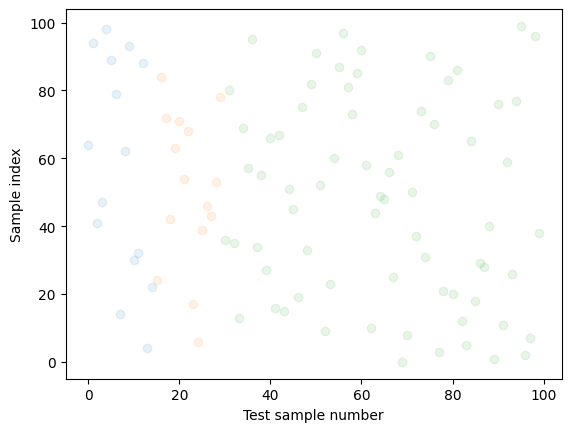

In [101]:
# Plot of test_indices and train_indices

plt.scatter(range(N_test), testing_indices, alpha=0.1)
plt.scatter(np.arange(N_val)+N_test, validation_indices, alpha=0.1)
plt.scatter(np.arange(N_train)+N_test+N_val, training_indices, alpha=0.1)

plt.xlabel('Test sample number')
plt.ylabel('Sample index')

In [104]:
num_params = 10

data_array = np.empty((N_total, num_params), dtype=object)

# Definiere die Intervalle für die kosmologischen Parameter
param_intervals = {
    'Om_c': (0.05, 0.255),
    'Om_b': (0.01875, 0.02625),
    'h': (0.64, 0.82),
    'sigma_8': (0.8, 1),
    'n_s': (0.84, 1.1),
}

# Anzahl der Parameter (Dimensionen des LHS)
num_cosmo_params = len(param_intervals)

# Generiere Latin Hypercube Samples (LHS)
lhs_samples = lhs(num_cosmo_params, samples=N_total)

# Skaliere die LHS-Samples auf die jeweiligen Intervalle
cosmo_samples = []
for sample in lhs_samples:
    cosmo = {
        key: param_intervals[key][0] + (param_intervals[key][1] - param_intervals[key][0]) * sample[i]
        for i, key in enumerate(param_intervals)
    }
    cosmo_samples.append(cosmo)

# Halo mass function
hmf = ccl.halos.MassFuncSheth99()

# Halo bias
hbf = ccl.halos.HaloBiasSheth01()

# Concentration mass Relation
cmfunc = ccl.halos.ConcentrationDuffy08()

# HOD-Parameter
alpha = 1
sigma = 0.2
Mth = 1e12
Mprime = 20 * Mth
beta = 1

# Korrelation zwischen Galaxienpopulationen
A = 0  # 0 ==> Keine Korrelation zwischen Populationen
epsilon = 0

# Skalierung des Halo-Profils
flens = 1  # 1 ==> Gleiches Profil wie dunkle Materie

data_array = []

Pk_ss_1h = [1] * 50  # Platzhalter für die 50 Werte
Pk_ss_2h = [2] * 50
Pk_ss = [3] * 50
Pk_sl_1h = [4] * 50
Pk_sl_2h = [5] * 50
Pk_sl = [6] * 50
Pk_ll_1h = [7] * 50
Pk_ll_2h = [8] * 50
Pk_ll = [9] * 50
Pk_lin = [10] * 50

# Hauptschleife für Simulationen
for i in range(N_total):
    # Kosmologische Parameter aus LHS entnehmen
    cosmo = cosmo_samples[i]
    cosmo_array = np.array(list(cosmo.values()))


    # HOD abrufen
    hod_cen, hod_sat = g3lhalo.HOD_Zheng(alpha, Mth, sigma, Mprime, beta)

    # Modell definieren
    model = g3lhalo.halomodel(verbose=True, cosmo=cosmo, hmfunc=hmf, hbfunc=hbf, cmfunc=cmfunc)
    model.set_hods(hod_cen, hod_sat, A=A, epsilon=epsilon, flens1=flens, flens2=flens)

    # Berechnungen durchführen
    ks = np.geomspace(1e-2, 1e2)
    z = 0

    # Lineares Materie-Leistungsspektrum
    Pk_lin = model.pk_lin(ks, z)

    # Materie-Materie Leistungsspektrum
    Pk_ss_1h, Pk_ss_2h, Pk_ss = model.source_source_ps(ks, z)

    # Materie-Galaxie Leistungsspektrum
    Pk_sl_1h, Pk_sl_2h, Pk_sl = model.source_lens_ps(ks, z, type=1)

    # Galaxie-Galaxie Leistungsspektrum
    Pk_ll_1h, Pk_ll_2h, Pk_ll = model.lens_lens_ps(ks, z, type1=1, type2=1)
    

    # Erstelle das Dictionary mit den Daten für das aktuelle Sample
    data_dict = {
        'Pk_ss_1h': Pk_ss_1h,
        'Pk_ss_2h': Pk_ss_2h,
        'Pk_ss': Pk_ss,
        'Pk_sl_1h': Pk_sl_1h,
        'Pk_sl_2h': Pk_sl_2h,
        'Pk_sl': Pk_sl,
        'Pk_ll_1h': Pk_ll_1h,
        'Pk_ll_2h': Pk_ll_2h,
        'Pk_ll': Pk_ll,
        'Pk_lin': Pk_lin,
    }
    
    # Füge das Dictionary für dieses Sample der Liste hinzu
    data_array.append(data_dict)

    print(f"Run {i+1}/{N_total} completed")


Setting cosmology
Om_c: 0.1349180623479304
Om_b: 0.01949464655478532
h: 0.8052255205131844
sigma_8: 0.8899317105751998
n_s: 0.8724209851462182
Also setting linear matter power spectrum
Setting halo mass function
Setting halo bias function
Setting concentration mass relation
Run 1/100 completed
Setting cosmology
Om_c: 0.12309475608858964
Om_b: 0.024432254311692214
h: 0.8001002943460169
sigma_8: 0.9025260428526577
n_s: 1.006072659278832
Also setting linear matter power spectrum
Setting halo mass function
Setting halo bias function
Setting concentration mass relation
Run 2/100 completed
Setting cosmology
Om_c: 0.1378545349160179
Om_b: 0.022633163542901985
h: 0.7093625051997394
sigma_8: 0.8150714251540243
n_s: 0.869140239568591
Also setting linear matter power spectrum
Setting halo mass function
Setting halo bias function
Setting concentration mass relation
Run 3/100 completed
Setting cosmology
Om_c: 0.1507376110995642
Om_b: 0.020996642324978842
h: 0.6630352878981034
sigma_8: 0.91792183452

## Save generated data

In [105]:
# Funktion, die rekursiv alle np.ndarrays in Listen umwandelt
def convert_to_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()  # Umwandlung in eine Python-Liste
    elif isinstance(obj, list):
        return [convert_to_serializable(item) for item in obj]  # Rekursive Umwandlung der Listenelemente
    elif isinstance(obj, dict):
        return {key: convert_to_serializable(value) for key, value in obj.items()}  # Rekursive Umwandlung der Dictionary-Werte
    else:
        return obj  # Für alle anderen Typen keine Änderung

# Konvertiere alle numpy.ndarrays in data_array
data_array_serializable = [convert_to_serializable(sublist) for sublist in data_array]

# Anzahl der generierten Daten
num_data_points = len(data_array_serializable)

# Verzeichnis für die gespeicherten Daten
data_dir = "../Data/"
os.makedirs(data_dir, exist_ok=True)

# Erzeuge einen einzigartigen Dateinamen mit Zeitstempel
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
data_fn = f"{data_dir}/GeneratedData_{num_data_points}_{timestamp}.json"

# Speichern der Daten
with open(data_fn, "w") as json_file:
    json.dump(data_array_serializable, json_file, indent=4)

print(f"Daten erfolgreich gespeichert in: {data_fn}")


Daten erfolgreich gespeichert in: ../Data//GeneratedData_100_2025-04-03_16-48-49.json


## Save related parameter

In [107]:
para_fn = f"{data_dir}/Parameter_{num_data_points}_{timestamp}.json"
# Speichern der Daten
with open(para_fn, "w") as json_file:
    json.dump(cosmo_samples, json_file, indent=4)

print(f"Daten erfolgreich gespeichert in: {data_fn}")

Daten erfolgreich gespeichert in: ../Data//GeneratedData_100_2025-04-03_16-48-49.json


## Read generated Data

In [121]:
import json
import numpy as np

# Dateipfad zur gespeicherten JSON-Datei
data_fn = f"{data_dir}/GeneratedData_100_2025-04-03_16-48-49.json"

# Daten einlesen
with open(data_fn, "r") as json_file:
    data_samples = json.load(json_file)

# Definiere die Keys, die du für die Pk_*-Daten brauchst
data_keys = [
    'Pk_ss_1h', 'Pk_ss_2h', 'Pk_ss', 
    'Pk_sl_1h', 'Pk_sl_2h', 'Pk_sl', 
    'Pk_ll_1h', 'Pk_ll_2h', 'Pk_ll', 
    'Pk_lin'
]

# Erstellen von numpy Arrays für jede der Pk_* Spalten
data_arrays = {key: np.array([sample[key] for sample in data_samples]) for key in data_keys}

# Aufteilen der Daten in Trainings-, Validierungs- und Test-Daten
training_data = {key: data[training_indices] for key, data in data_arrays.items()}
validation_data = {key: data[validation_indices] for key, data in data_arrays.items()}
testing_data = {key: data[testing_indices] for key, data in data_arrays.items()}


## Read parameter

In [119]:
para_fn = f"{data_dir}/Parameter_100_2025-04-03_16-48-49.json"
# Read in
with open(para_fn, "r") as json_file:
    samples = json.load(json_file)


# Erstellen von numpy Arrays für jede der Parameter-Spalten
parameter_keys = ['Om_c', 'Om_b', 'h', 'sigma_8', 'n_s']

# Liste von Arrays für jeden Parameter
parameter_arrays = {key: np.array([sample[key] for sample in samples]) for key in parameter_keys}

# Aufteilen der Daten in Trainings-, Validierungs- und Test-Daten
training_parameters = {key: param[training_indices] for key, param in parameter_arrays.items()}
validation_parameters = {key: param[validation_indices] for key, param in parameter_arrays.items()}
testing_parameters = {key: param[testing_indices] for key, param in parameter_arrays.items()}


NN

In [ ]:
# Angenommene Dimensionen
input_data = np.zeros((num_runs, 5))  # 10 Durchläufe mit 5 Eingabewerten
output_data = np.zeros((num_runs, 9, 50))  # 10 Durchläufe mit 3 Arrays à 50 (Shape: (3, 50))

# Dummy-Training-Daten generieren
for i in range(num_runs):
    # Zufällige Eingabewerte für jeden Durchlauf (Shape: 5)
    input_data[i] = data_array[i][0]

    # Zufällige Ausgabewerte für die 3 Arrays (Shape: 50)
    output_data[i, 0, :] = data_array[i][1]
    output_data[i, 1, :] = data_array[i][2]
    output_data[i, 2, :] = data_array[i][3]
    output_data[i, 3, :] = data_array[i][4]
    output_data[i, 4, :] = data_array[i][5]
    output_data[i, 5, :] = data_array[i][6]
    output_data[i, 6, :] = data_array[i][7]
    output_data[i, 7, :] = data_array[i][8]
    output_data[i, 8, :] = data_array[i][9]

# Trenne Trainings- und Vorhersagedaten
X_train = input_data[:(num_runs-1)]  # Die ersten 9 Durchläufe als Trainingsdaten
y_train = output_data[:(num_runs-1)]  # Die ersten 9 Ausgabewerte als Trainingsdaten

X_test = input_data[(num_runs-1):]  # Der 10. Durchlauf für die Vorhersage
y_test = output_data[(num_runs-1):]  # Der 10. Durchlauf für die tatsächlichen Werte (zum Überprüfen)

# Baue das Modell
model = Sequential()

early_stopping = EarlyStopping(
    monitor='loss',  # Überwacht den Validierungs-Loss
    patience=25,         # Stoppt das Training, wenn sich der Loss 10 Epochen lang nicht verbessert
    restore_best_weights=True  # Setzt die Gewichte auf die beste Epoche zurück
)

# Eingabeschicht: 5 Eingabewerte
model.add(Dense(64, input_dim=5, activation='relu'))  # Erste verborgene Schicht mit 64 Neuronen

# Eine weitere verborgene Schicht
model.add(Dense(128, activation='relu'))  # Zweite verborgene Schicht mit 128 Neuronen

# Eine weitere verborgene Schicht
model.add(Dense(128, activation='relu'))  # Zweite verborgene Schicht mit 128 Neuronen

# Ausgabeschicht: 9 Arrays der Shape (50,)
model.add(Dense(450, activation='linear'))  # Wir brauchen 150 Ausgabewerte insgesamt (3 Arrays à 50 Werte)

# Kompiliere das Modell
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mean_squared_error')

# Trainiere das Modell
history = model.fit(X_train, y_train.reshape((num_runs-1, 450)), batch_size=16, epochs=300, verbose=1, validation_split=0.1, callbacks=[early_stopping])

# Vorhersage mit dem Modell für den 10. Durchlauf
predictions = model.predict(X_test)

# Die Ausgabe wird in einem flachen Array gespeichert, daher müssen wir es wieder aufteilen
output1 = predictions[:, :50]
output2 = predictions[:, 50:100]
output3 = predictions[:, 100:150]
output4 = predictions[:, 150:200]
output5 = predictions[:, 200:250]
output6 = predictions[:, 250:300]
output7 = predictions[:, 300:350]
output8 = predictions[:, 350:400]
output9 = predictions[:, 400:]

print(history)



Epoch 1/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 6146095616.0000 - val_loss: 6920059904.0000
Epoch 2/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7062490624.0000 - val_loss: 6744524800.0000
Epoch 3/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6269806592.0000 - val_loss: 5713206784.0000
Epoch 4/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4961373184.0000 - val_loss: 4241401344.0000
Epoch 5/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2697786624.0000 - val_loss: 3714675712.0000
Epoch 6/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2085927936.0000 - val_loss: 3561328896.0000
Epoch 7/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 2256185344.0000 - val_loss: 3506532096.0000
Epoch 8/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2412324608.0000 - val_loss: 3471611648.0000
Epoch 9/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2354147328.0000 - val_loss: 3470535936.0000
Epoch 10/300
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2405100800

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17983652.0000  


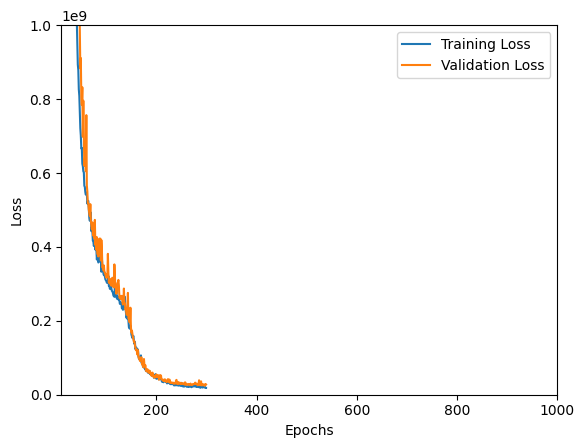

In [11]:
loss = model.evaluate(X_train, y_train.reshape((num_runs-1, 450)))
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.xlim(10, 1000)
plt.ylim(0, 1e9)
plt.show()

# Plot Prediction

In [337]:
Pk_ss_1h_pred = output1.squeeze()
Pk_ss_2h_pred = output2.squeeze()
Pk_ss_pred = output3.squeeze()
Pk_sl_1h_pred = output4.squeeze()
Pk_sl_2h_pred = output5.squeeze()
Pk_sl_pred = output6.squeeze()
Pk_ll_1h_pred = output7.squeeze()
Pk_ll_2h_pred = output8.squeeze()
Pk_ll_pred = output9.squeeze()

(1, 10000000.0)

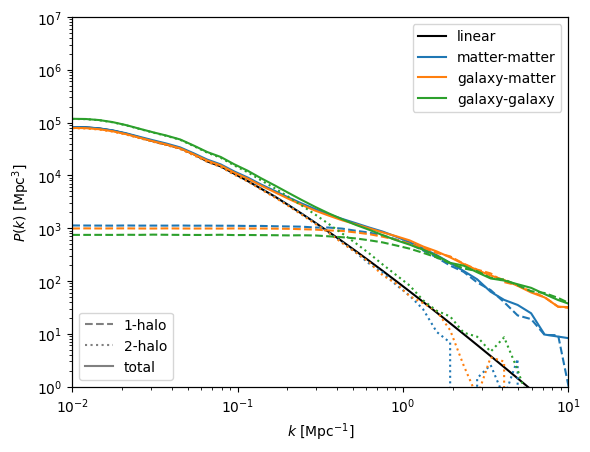

In [338]:

fig, axes=plt.subplots()
axes.loglog(ks, Pk_lin, color='k', label='linear')


axes.loglog(ks, Pk_ss_1h_pred, color='C0', ls='--')
axes.loglog(ks, Pk_ss_2h_pred, color='C0', ls=':')
axes.loglog(ks, Pk_ss_pred, color='C0', label='matter-matter')

axes.loglog(ks, Pk_sl_1h_pred, color='C1', ls='--')
axes.loglog(ks, Pk_sl_2h_pred, color='C1', ls=':')
axes.loglog(ks, Pk_sl_pred, color='C1', label='galaxy-matter')

axes.loglog(ks, Pk_ll_1h_pred, color='C2', ls='--')
axes.loglog(ks, Pk_ll_2h_pred, color='C2', ls=':')
axes.loglog(ks, Pk_ll_pred, color='C2', label='galaxy-galaxy')


plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$P(k)$ [Mpc$^{3}$]')


ax2=axes.twinx()
ax2.plot(np.NaN, np.NaN, ls='--', label='1-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls=':', label='2-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls='-', label='total', color='grey')



axes.legend()
ax2.legend(loc='lower left')
ax2.set_yticks([])

axes.set_xlim(1e-2,10)
axes.set_ylim(1, 1e7)

# Plot Calc

(1, 10000000.0)

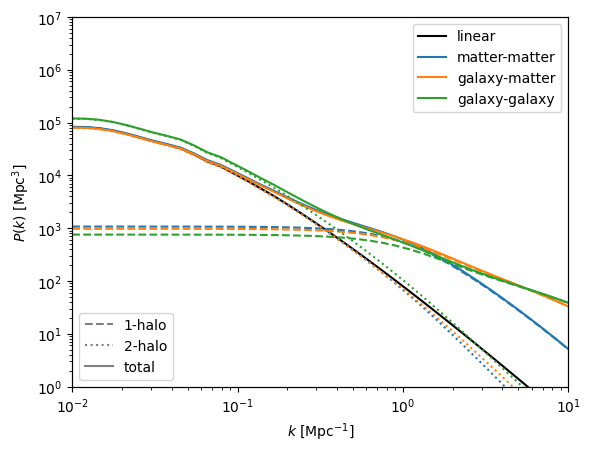

In [330]:
fig, axes=plt.subplots()
axes.loglog(ks, Pk_lin, color='k', label='linear')


axes.loglog(ks, y_test[0][0], color='C0', ls='--')
axes.loglog(ks, y_test[0][1], color='C0', ls=':')
axes.loglog(ks, y_test[0][2], color='C0', label='matter-matter')

axes.loglog(ks, y_test[0][3], color='C1', ls='--')
axes.loglog(ks, y_test[0][4], color='C1', ls=':')
axes.loglog(ks, y_test[0][5], color='C1', label='galaxy-matter')

axes.loglog(ks, y_test[0][6], color='C2', ls='--')
axes.loglog(ks, y_test[0][7], color='C2', ls=':')
axes.loglog(ks, y_test[0][8], color='C2', label='galaxy-galaxy')


plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$P(k)$ [Mpc$^{3}$]')


ax2=axes.twinx()
ax2.plot(np.NaN, np.NaN, ls='--', label='1-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls=':', label='2-halo', color='grey')
ax2.plot(np.NaN, np.NaN, ls='-', label='total', color='grey')



axes.legend()
ax2.legend(loc='lower left')
ax2.set_yticks([])

axes.set_xlim(1e-2,10)
axes.set_ylim(1, 1e7)